In [1]:
### Standard Library
from typing import TypeAlias
from dataclasses import dataclass

### Externals
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from sklearn.manifold import TSNE
# Torch
import torch
from torch import Tensor, nn, optim
from torch.utils.data.dataloader import DataLoader
from torch.nn.functional import mse_loss
import torch.autograd
# TorchVision
import torchvision
import torchvision.utils
from torchvision.datasets import MNIST
from torchvision import transforms


device = torch.device("cpu")

MNISTSample: TypeAlias = tuple[torch.Tensor, int]
MNISTBatch: TypeAlias = tuple[Tensor, Tensor]

In [2]:
@dataclass(frozen=True)
class Configs:
    """Project wide Configurations"""

    batch_size: int = 64
    shuffle_in_dataloader: bool = True
    regularizer_lambda: float = 1e-5

@dataclass(frozen=True)
class Constants:
    """Reusable Constants"""
    mnist_size: int = 28
    mnist_input_size: int = 28**2
    mnist_n_samples: int = 60000

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Lambda(torch.flatten)]
)
data_train = MNIST("./data", train=True, transform=transform, download=True)
data_test = MNIST("./data", train=False, transform=transform, download=True)

train_dataloader = DataLoader[MNISTSample](
    data_train, batch_size=Configs.batch_size, shuffle=Configs.shuffle_in_dataloader
)
test_dataloader = DataLoader[MNISTSample](
    data_test, batch_size=Configs.batch_size, shuffle=Configs.shuffle_in_dataloader
)

batch: MNISTBatch = next(iter(train_dataloader))
images, labels = batch

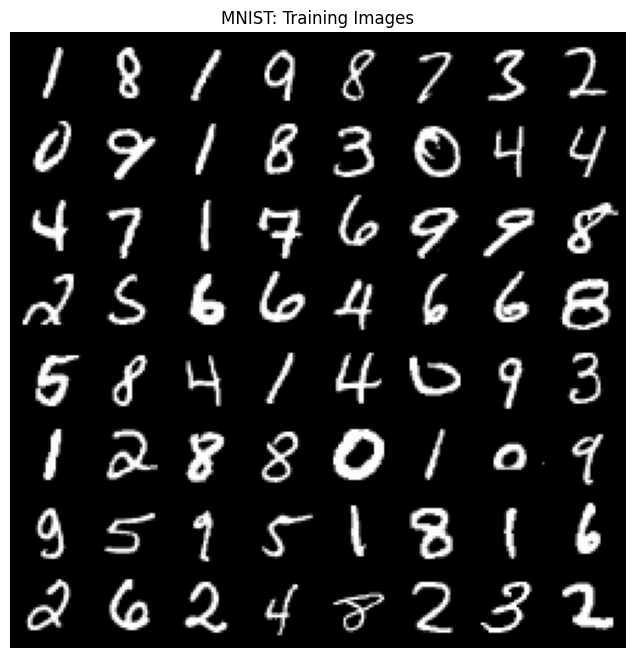

Labels:
[[1 8 1 9 8 7 3 2]
 [0 9 1 8 3 0 4 4]
 [4 7 1 7 6 9 9 8]
 [2 5 6 6 4 6 6 8]
 [5 8 4 1 4 0 9 3]
 [1 2 8 8 0 1 0 9]
 [9 5 9 5 1 8 1 6]
 [2 6 2 4 8 2 3 2]]


In [3]:
def plot_sample(images: Tensor, labels: Tensor) -> None:
    images = torchvision.utils.make_grid(
        images.view(
            Configs.batch_size, 1, Constants.mnist_size, Constants.mnist_size
        ),
        padding=2,
        normalize=True,
    )

    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title("MNIST: Training Images")
    plt.imshow(np.transpose(images, (1, 2, 0)))
    plt.show()

    print("Labels:")
    print(labels.reshape(-1, 8).numpy())
plot_sample(images=images, labels=labels)

In [4]:
from typing import TypedDict

class AutoEncoderOutput(TypedDict):
    x_out: Tensor
    z: Tensor

class AutoEncoder(nn.Module):
    def __init__(self, num_latent_features: int):
        super().__init__() # type: ignore
        self.num_latent_features = num_latent_features

        self.encoder = nn.Sequential(
            nn.Linear(Constants.mnist_input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, self.num_latent_features)
        )

        self.decoder = nn.Sequential(
            nn.Linear(num_latent_features, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, Constants.mnist_input_size),
            nn.Sigmoid()
        )

    def forward(self, x: Tensor) -> AutoEncoderOutput:
        z: Tensor = self.encoder(x)
        x_out: Tensor = self.decoder(z)

        return AutoEncoderOutput(
            x_out = x_out,
            z = z
        )

In [5]:
model = AutoEncoder(num_latent_features=10)
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [6]:
def ae_loss(decoder_output: AutoEncoderOutput, encoder_input: Tensor) -> Tensor:
    """Must return a scalar Tensor not a python float"""
    l2_loss= mse_loss(input=decoder_output["x_out"], target=encoder_input)
    l1_reg = decoder_output["z"].abs().mean()
    return l2_loss + Configs.regularizer_lambda * l1_reg

lr = 0.001
optimiser = optim.Adam(model.parameters(), lr = lr)
loss_function = ae_loss

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0234 =======


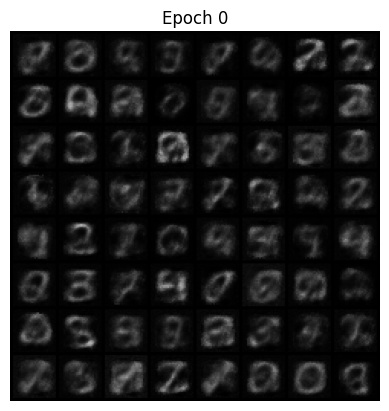

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0193 =======


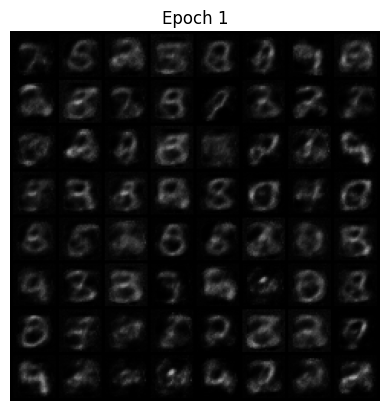

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0177 =======


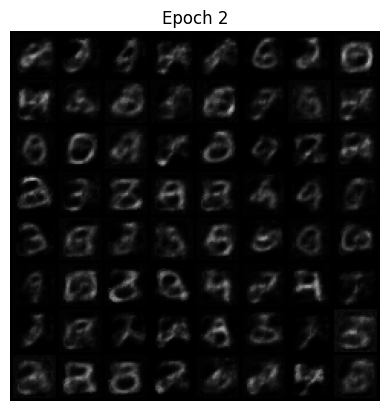

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0167 =======


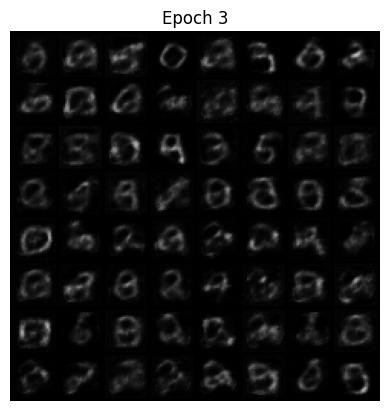

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0159 =======


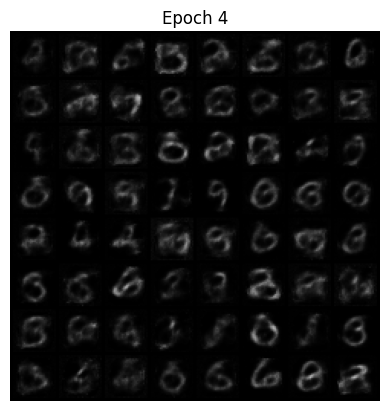

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0155 =======


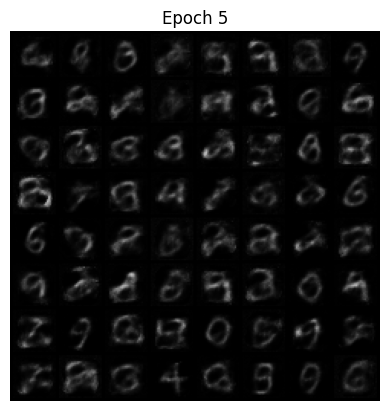

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0149 =======


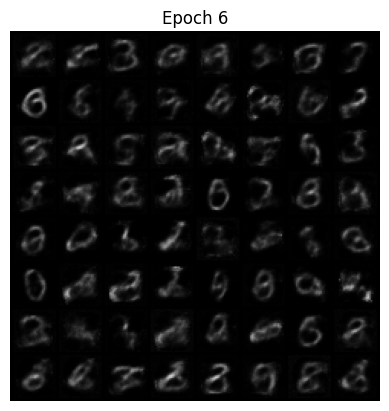

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0146 =======


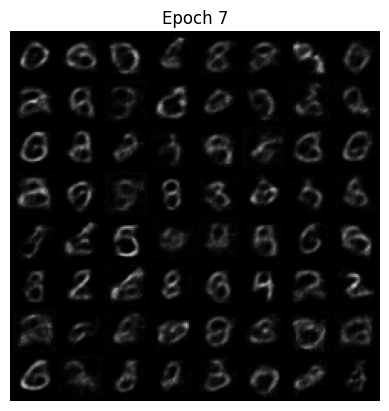

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0144 =======


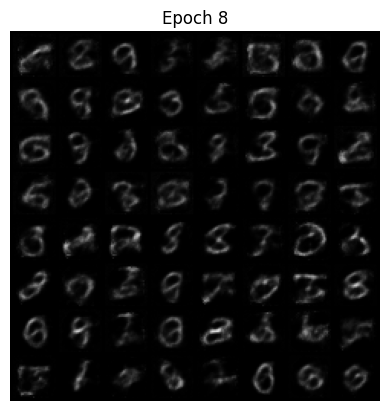

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0143 =======


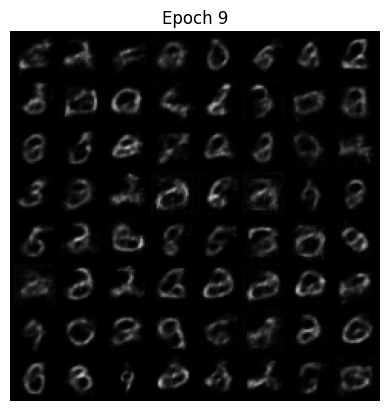

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0141 =======


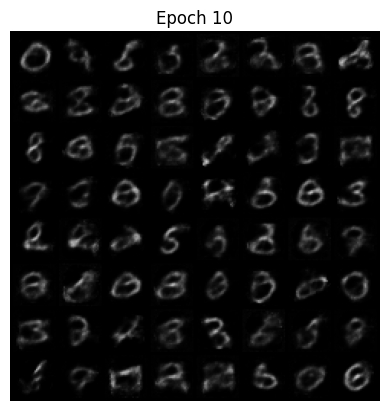

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0140 =======


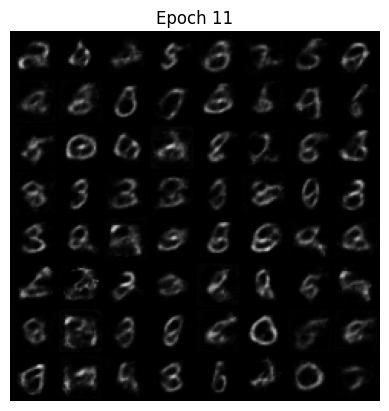

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0138 =======


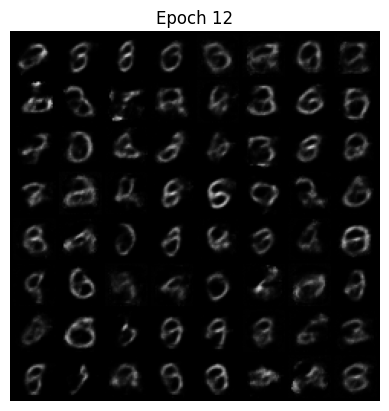

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0135 =======


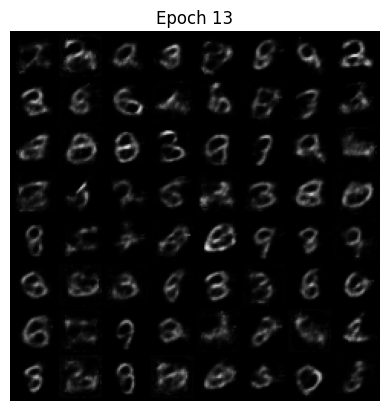

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0134 =======


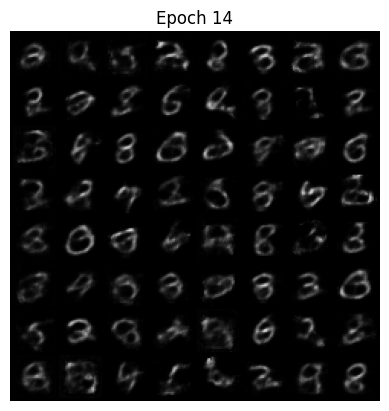

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0133 =======


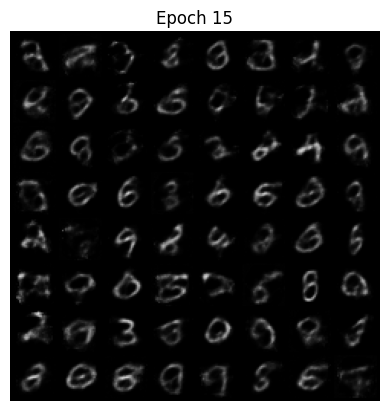

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0133 =======


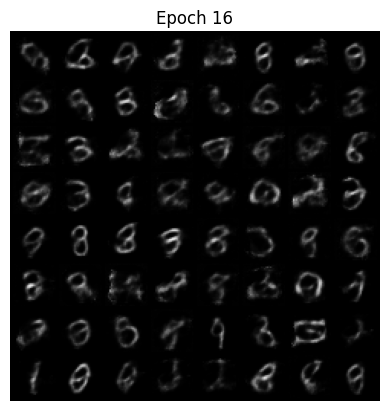

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0133 =======


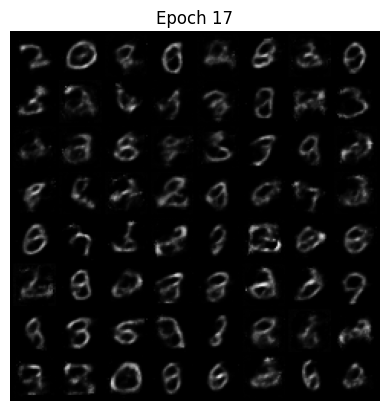

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0131 =======


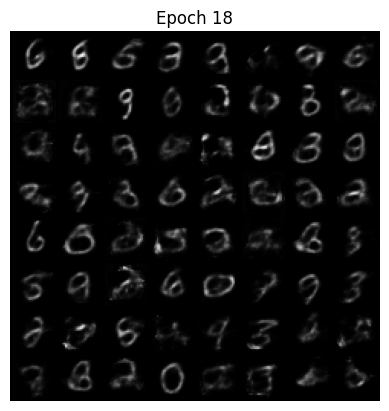

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0130 =======


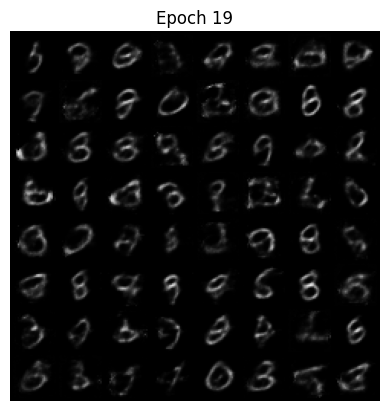

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0130 =======


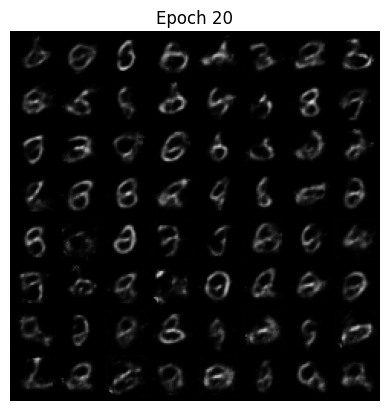

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0129 =======


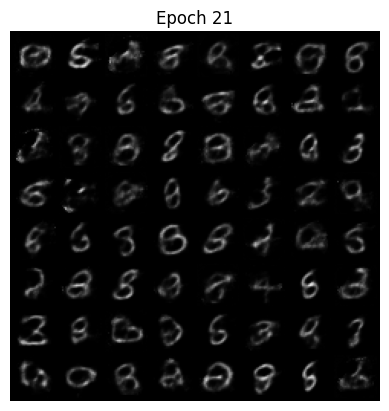

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0129 =======


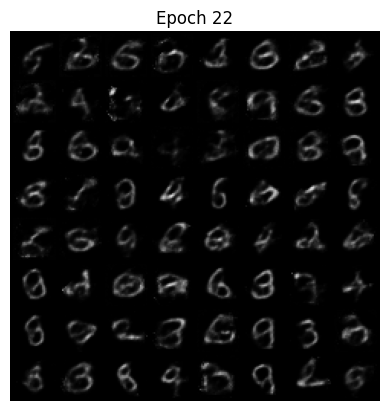

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0129 =======


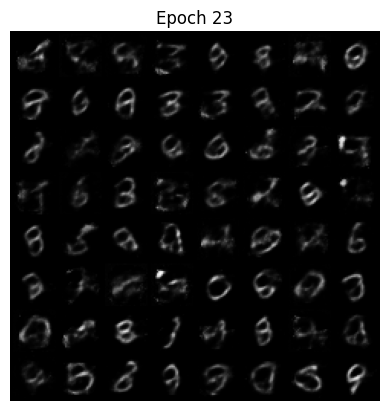

  0%|          | 0/938 [00:00<?, ?batch/s]

  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0128 =======


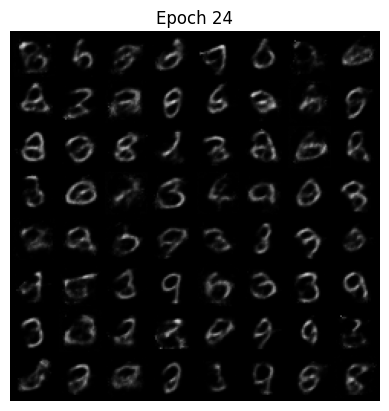

In [7]:
epochs = 25

train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    with tqdm(train_dataloader, unit="batch") as train_epoch_pbar:
        for data, labels in train_epoch_pbar:
            data = data.to(device)
            train_epoch_pbar.set_description(f"Epoch {epoch + 1}")

            optimiser.zero_grad()

            output = model(data)
            loss = ae_loss(output, data)

            loss.backward()
            optimiser.step()

            train_loss += loss.item()
            avg_batch_loss = loss.item() / len(data)
            train_epoch_pbar.set_postfix(loss = avg_batch_loss)
        
        avg_epoch_loss = train_loss / len(train_dataloader)
        train_losses.append(avg_epoch_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        with tqdm(test_dataloader, unit="batch") as test_pbar:
            for data, labels in test_pbar:
                data = data.to(device)
                test_pbar.set_description("test")

                output = model(data)
                test_loss += ae_loss(output, data).item()

    test_loss /= len(test_dataloader)
    print(f"======= Test set loss: {test_loss:.4f} =======")
    test_losses.append(test_loss)

    with torch.no_grad():
        sample = torch.randn(Configs.batch_size, model.num_latent_features).to(device)
        sample = model.decoder(sample).detach().cpu()
        image_grid = torchvision.utils.make_grid(
            sample.view(Configs.batch_size, 1, Constants.mnist_size, Constants.mnist_size),
            nrow = 8
        ).permute(1, 2, 0)
        plt.imshow(image_grid.numpy(), cmap="gray")
        plt.axis("off")
        plt.title(f"Epoch {epoch}")
        plt.show()

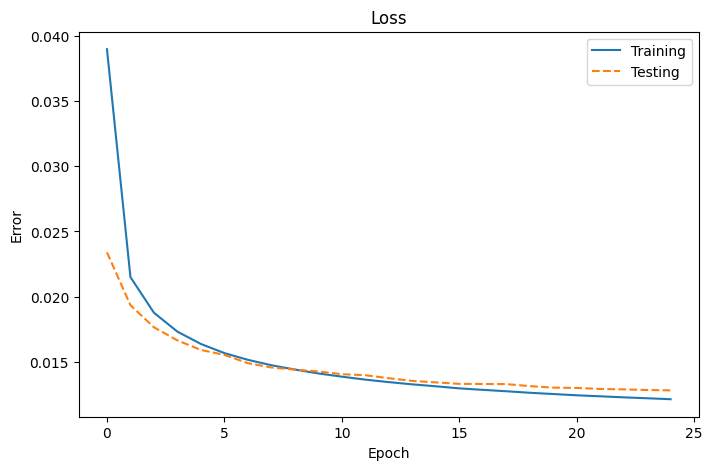

In [8]:
# Plotting
f, axarr = plt.subplots(1, 1, figsize=(8, 5))

# Loss
ax = axarr
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Error")

ax.plot(np.arange(epochs), train_losses)
ax.plot(np.arange(epochs), test_losses, linestyle="--")
ax.legend(["Training", "Testing"])

In [9]:
def show_thresholded_reconstruction(model: nn.Module, dataloader: DataLoader, threshold: float = 0.5):
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            output = model(x)["x_out"]
            recon = output.view(-1, 1, Constants.mnist_size, Constants.mnist_size).cpu()
            x = x.view(-1, 1, Constants.mnist_size, Constants.mnist_size).cpu()
            break  # just one batch

    recon_thresh = (recon > threshold).float()

    n = 8
    fig, axes = plt.subplots(3, n, figsize=(n * 1.2, 4))
    for i in range(n):
        axes[0, i].imshow(x[i][0], cmap="gray")
        axes[1, i].imshow(recon[i][0], cmap="gray")
        axes[2, i].imshow(recon_thresh[i][0], cmap="gray")

        for ax in axes[:, i]:
            ax.axis("off")

    axes[0, 0].set_title("Original")
    axes[1, 0].set_title("Reconstruction")
    axes[2, 0].set_title(f"Thresholded @ {threshold:.2f}")
    plt.tight_layout()
    plt.show()

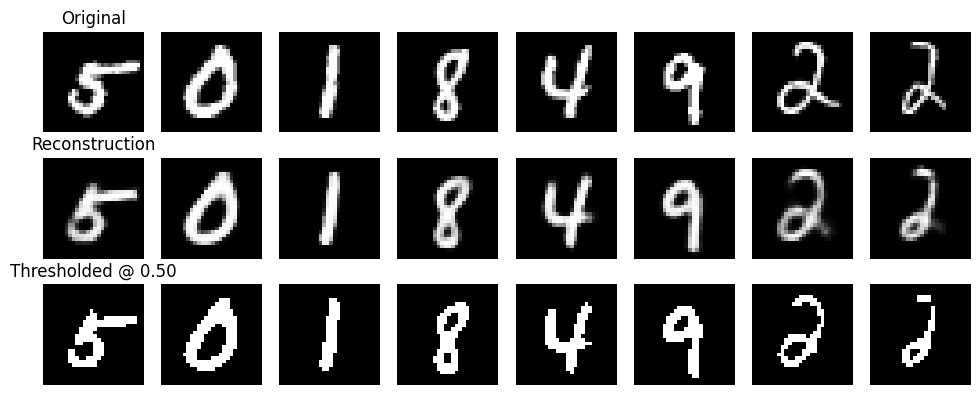

In [10]:
show_thresholded_reconstruction(model, test_dataloader, threshold=0.5)

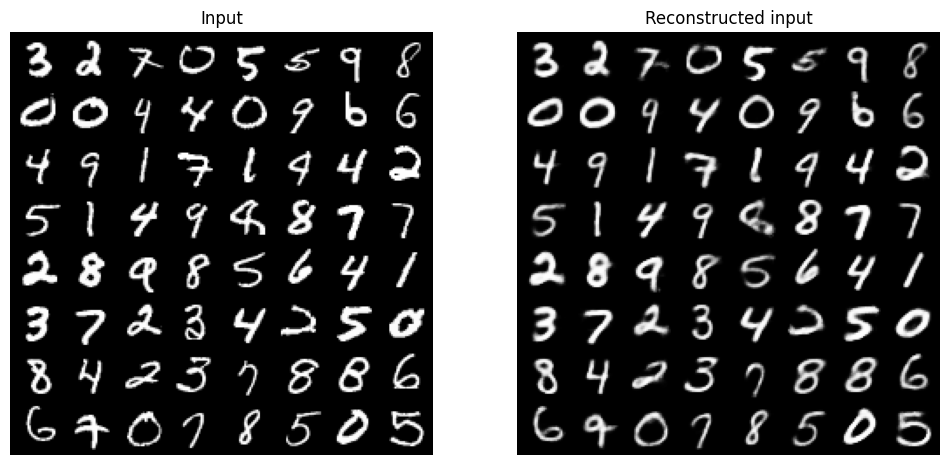

In [11]:
f, axarr = plt.subplots(1, 2, figsize=(12, 12))

with torch.no_grad():
    x, _ = next(iter(train_dataloader))
    x = torch.autograd.Variable(x)
    x = x.to(device)
    outputs = model(x)
    x_out = outputs["x_out"].detach().cpu()
    x = x.detach().cpu()

    image_grid = torchvision.utils.make_grid(x.view(Configs.batch_size, 1, 28, 28), nrow=8).permute(1, 2, 0)
    axarr[0].imshow(image_grid.numpy())
    axarr[0].set_title("Input")
    axarr[0].axis("off")

    image_grid = torchvision.utils.make_grid(x_out.view(Configs.batch_size, 1, 28, 28), nrow=8).permute(1, 2, 0)
    axarr[1].imshow(image_grid.numpy())
    axarr[1].set_title("Reconstructed input")
    axarr[1].axis("off")

In [12]:
def generate_visualisation(latent: Tensor, labels: Tensor) -> None:
    """
    Plot a 2-D t-SNE projection of the auto-encoder’s latent vectors.

    Parameters
    ----------
    latent : Tensor  [N, latent_dim]
        Latent codes produced by the encoder.
    labels : Tensor  [N]
        Ground-truth digit labels used to colour the points.
    """
    # Fit t-SNE
    latent_embedded = TSNE(
        n_components=2,
        init="random",
        learning_rate="auto"
    ).fit_transform(latent)

    # Plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        latent_embedded[:, 0],
        latent_embedded[:, 1],
        c=labels,
        cmap="Spectral",
        marker="o",
        edgecolor="none"
    )
    plt.xlabel("t-SNE component 1")
    plt.ylabel("t-SNE component 2")
    plt.title("2-D t-SNE embedding of the latent space")
    cbar = plt.colorbar(scatter, boundaries=np.arange(11) - 0.5)
    cbar.set_ticks(np.arange(10))
    cbar.set_label("Digit label (0 – 9)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def visualize_embeddings(model, train_dataloader):
    with torch.no_grad():
        x, labels = next(iter(train_dataloader))
        x = torch.autograd.Variable(x)
        x = x.to(device)
        outputs = model(x)
        z = outputs["z"].cpu()
        generate_visualisation(z, labels)

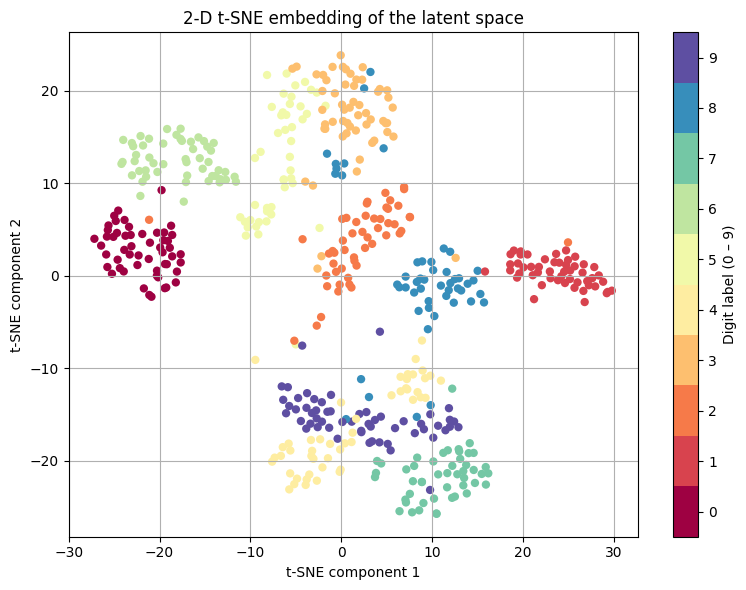

In [13]:
# Increase the batch size for a nicer plot
dataloader = DataLoader(data_train, batch_size=512, shuffle=True)
visualize_embeddings(model, dataloader)

In [14]:
normal = torch.distributions.Normal(0.5, 0.5)

class AdditiveGaussianNoise(nn.Module):
    def __init__(self, plot=False):
        super().__init__()
        self.plot = plot

    def forward(self, x):
        """Every PyTorch Module object has a self.training boolean which can be used
        to check if we are in training (True) or evaluation (False) mode."""
        if self.training or self.plot:
            device = x.device
            return x + normal.sample(sample_shape=torch.Size(x.shape)).to(device)
        else:
            return x

num_input_features = 28**2


class DenoisingAutoEncoder(AutoEncoder):
    def __init__(self, num_latent_features):
        super().__init__(num_latent_features)
        
        self.encoder = nn.Sequential(
            AdditiveGaussianNoise(),
            nn.Linear(Constants.mnist_input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, self.num_latent_features)
        )

num_latent_features = 10
model = DenoisingAutoEncoder(num_latent_features).to(device)
print(model)

DenoisingAutoEncoder(
  (encoder): Sequential(
    (0): AdditiveGaussianNoise()
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [15]:
"""Define the optimizer parameters"""
lr = 0.001
optimiser = optim.Adam(model.parameters(), lr=lr)
loss_function = ae_loss

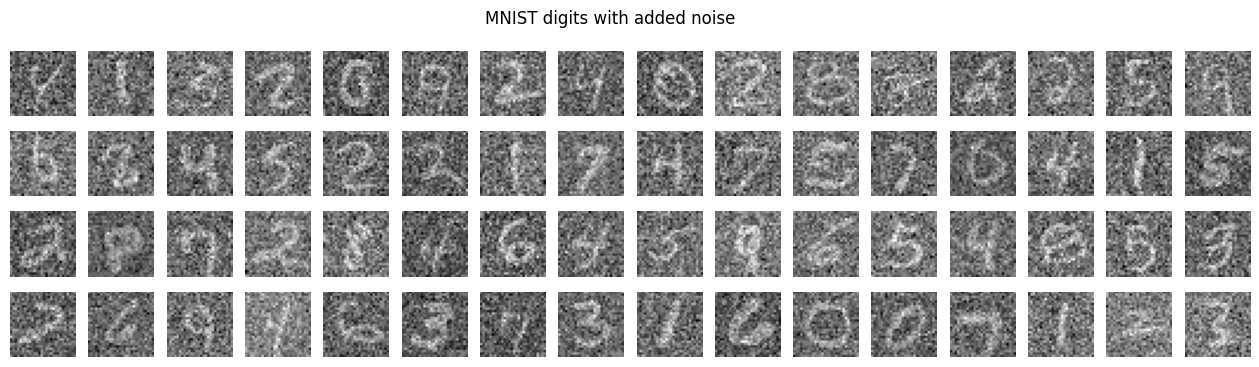

In [16]:
# plot the noisy examples
f, axarr = plt.subplots(4, 16, figsize=(16, 4))

# Load a batch of images into memory
images, labels = next(iter(train_dataloader))
noise = AdditiveGaussianNoise(plot=True)
for i, ax in enumerate(axarr.flat):
    ax.imshow(noise(images[i]).view(28, 28), cmap="binary_r")
    ax.axis("off")

plt.suptitle("MNIST digits with added noise")
plt.show()

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 1 Average Training loss: 0.0515 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0402 =======


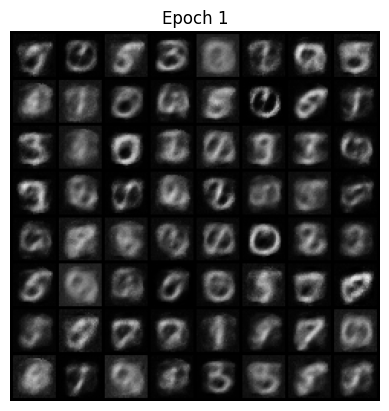

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 2 Average Training loss: 0.0318 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0300 =======


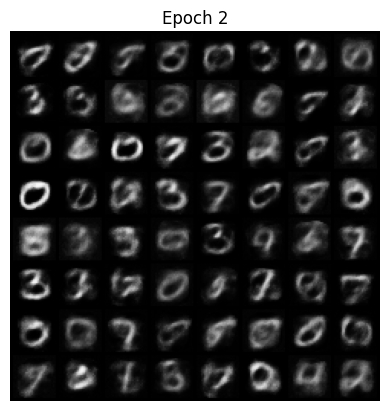

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 3 Average Training loss: 0.0275 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0249 =======


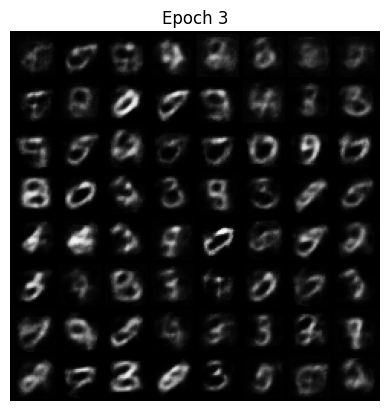

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 4 Average Training loss: 0.0253 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0226 =======


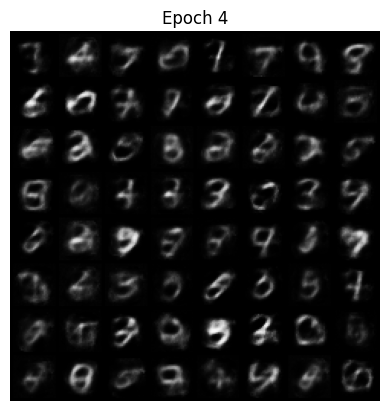

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 5 Average Training loss: 0.0241 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0212 =======


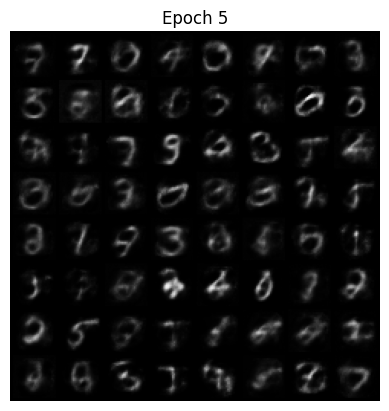

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 6 Average Training loss: 0.0233 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0212 =======


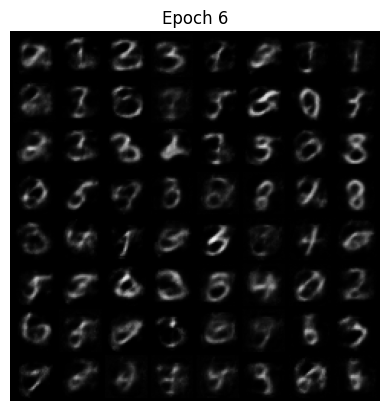

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 7 Average Training loss: 0.0226 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0224 =======


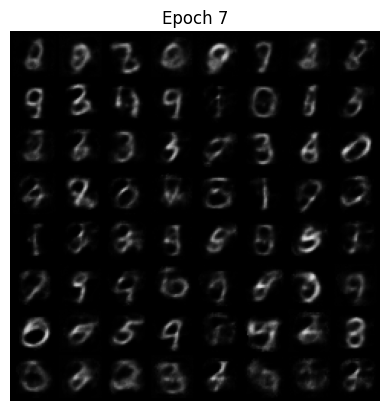

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 8 Average Training loss: 0.0222 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0223 =======


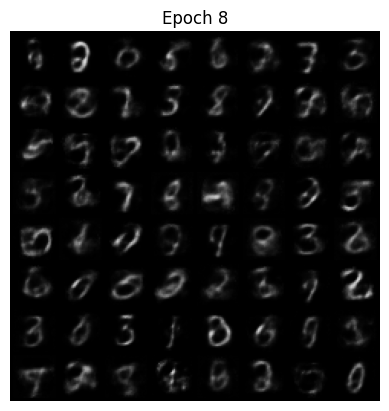

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 9 Average Training loss: 0.0218 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0225 =======


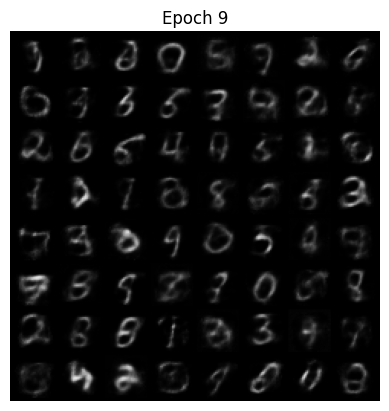

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 10 Average Training loss: 0.0215 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0246 =======


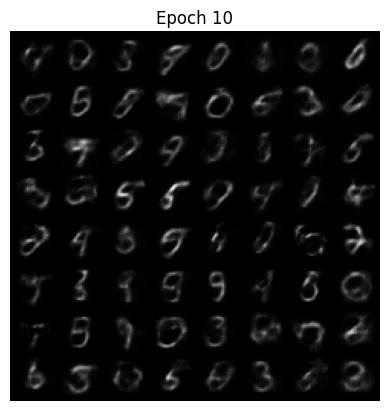

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 11 Average Training loss: 0.0212 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0263 =======


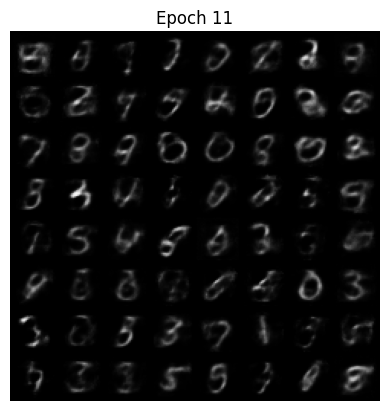

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 12 Average Training loss: 0.0210 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0256 =======


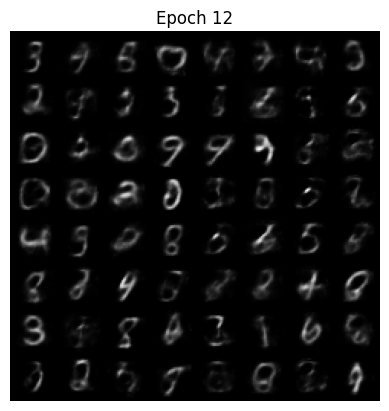

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 13 Average Training loss: 0.0207 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0286 =======


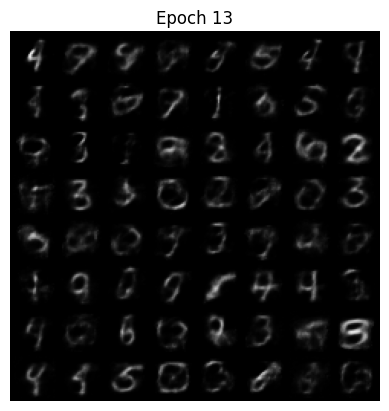

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 14 Average Training loss: 0.0206 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0288 =======


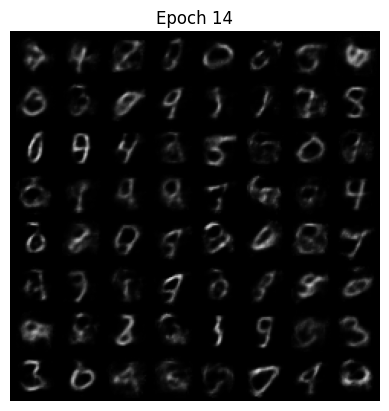

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 15 Average Training loss: 0.0204 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0300 =======


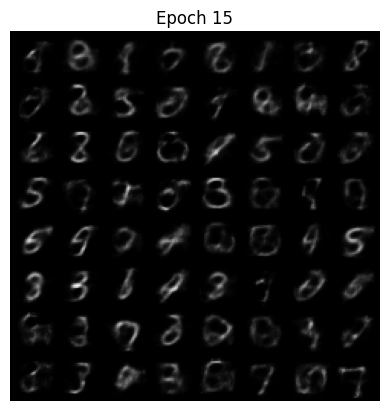

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 16 Average Training loss: 0.0203 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0324 =======


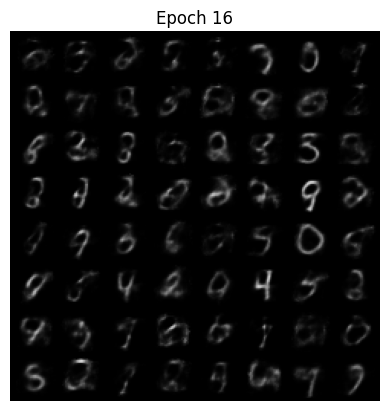

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 17 Average Training loss: 0.0201 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0330 =======


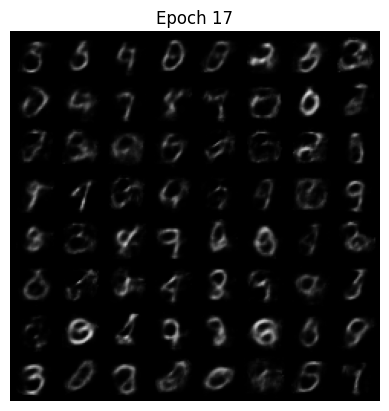

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 18 Average Training loss: 0.0201 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0328 =======


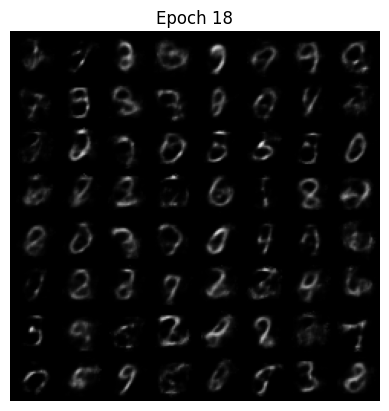

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 19 Average Training loss: 0.0199 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0350 =======


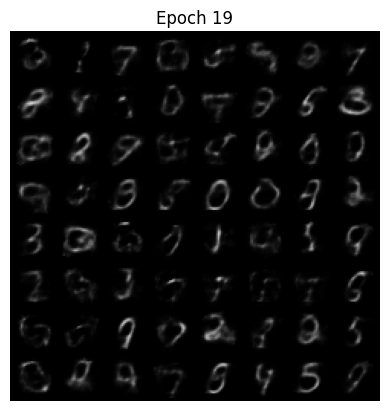

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 20 Average Training loss: 0.0198 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0351 =======


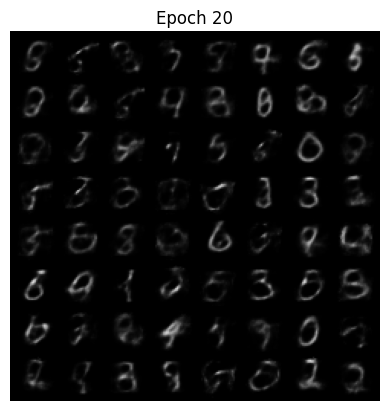

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 21 Average Training loss: 0.0198 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0357 =======


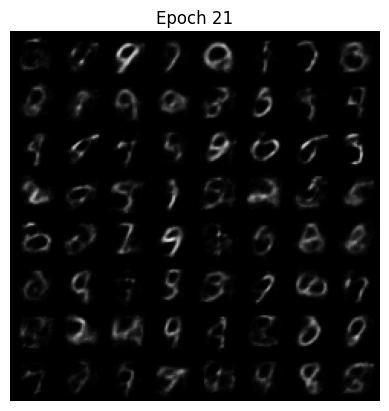

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 22 Average Training loss: 0.0197 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0365 =======


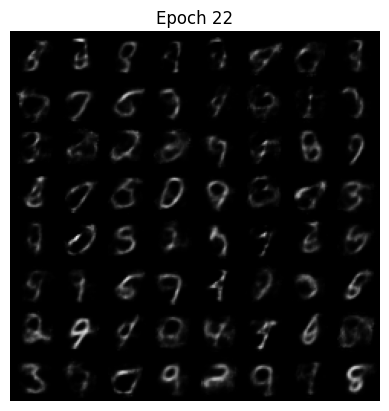

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 23 Average Training loss: 0.0196 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0394 =======


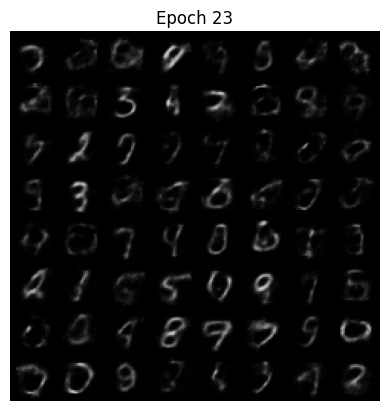

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 24 Average Training loss: 0.0195 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0385 =======


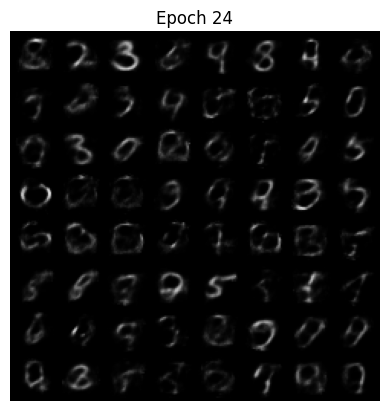

  0%|          | 0/938 [00:00<?, ?batch/s]

======= Epoch: 25 Average Training loss: 0.0194 =======


  0%|          | 0/157 [00:00<?, ?batch/s]

======= Test set loss: 0.0385 =======


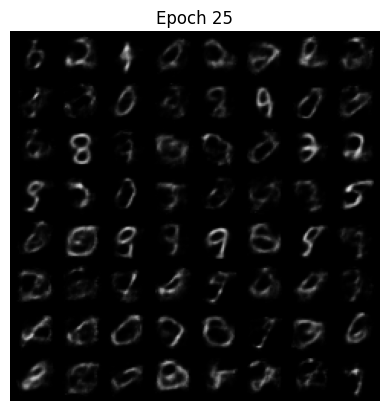

In [17]:
epochs = 25

train_loss_list = []
test_loss_list = []

for epoch in range(1, epochs + 1):
    ### =====TRAINING=====
    model.train()
    train_loss = 0
    with tqdm(train_dataloader, unit="batch") as train_epoch_pbar:
        for data, labels in train_epoch_pbar:
            train_epoch_pbar.set_description(f"Epoch {epoch}")
            data = data.to(device)

            """
            Calculate the loss for the current batch of inputs and 
            optimize the network parameters using the gradients.
            Variable `loss` should hold the loss value for current batch which 
            will be used to display the progress of training.
            """
            optimiser.zero_grad()

            output = model(data)
            loss = ae_loss(decoder_output=output, encoder_input=data)

            loss.backward()
            optimiser.step()

            train_loss += loss.item()
            avg_batch_loss = loss.item() / len(data)
            train_epoch_pbar.set_postfix(loss=avg_batch_loss)

        avg_epoch_loss = train_loss / len(train_dataloader)
        print(
            f"======= Epoch: {epoch} Average Training loss: {avg_epoch_loss:.4f} ======="
        )
        train_loss_list.append(avg_epoch_loss)

    ### =====TESTING=====
    model.eval()
    test_loss = 0
    with torch.no_grad():
        with tqdm(test_dataloader, unit="batch") as test_pbar:
            for data, labels in test_pbar:
                data = data.to(device)
                """
                Calculate the loss for the current test batch of inputs.
                Variable `loss` should hold the test set loss value for current batch which 
                will be used to display the progress of training.
                """
                output = model(data)
                test_loss += ae_loss(decoder_output=output, encoder_input=data)

    test_loss /= len(test_dataloader)
    print(f"======= Test set loss: {test_loss:.4f} =======")
    test_loss_list.append(test_loss)

    # Visualizing training progress
    with torch.no_grad():
        sample = torch.randn(Configs.batch_size, num_latent_features).to(device)
        sample = model.decoder(sample).detach().cpu()
        image_grid = torchvision.utils.make_grid(sample.view(Configs.batch_size, 1, 28, 28), nrow=8).permute(
            1, 2, 0
        )
        plt.imshow(image_grid.numpy(), cmap="gray")
        plt.axis("off")
        plt.title(f"Epoch {epoch}")
        plt.show()

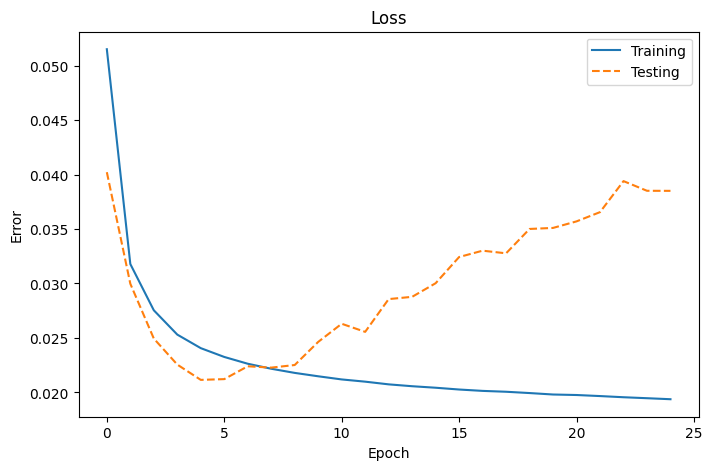

In [18]:
# Plotting
f, axarr = plt.subplots(1, 1, figsize=(8, 5))

# Loss
ax = axarr
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Error")

ax.plot(np.arange(epochs), train_loss_list)
ax.plot(np.arange(epochs), test_loss_list, linestyle="--")
ax.legend(["Training", "Testing"])

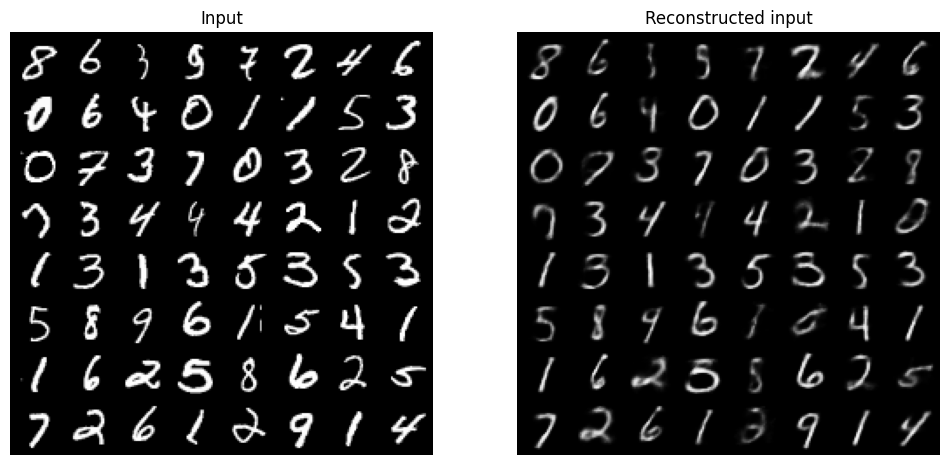

In [21]:
f, axarr = plt.subplots(1, 2, figsize=(12, 12))

with torch.no_grad():
    x, _ = next(iter(train_dataloader))
    x = torch.autograd.Variable(x)
    x = x.to(device)
    outputs = model(x)
    x_out = outputs["x_out"].detach().cpu()
    x = x.detach().cpu()

    image_grid = torchvision.utils.make_grid(x.view(Configs.batch_size, 1, 28, 28), nrow=8).permute(1, 2, 0)
    axarr[0].imshow(image_grid.numpy())
    axarr[0].set_title("Input")
    axarr[0].axis("off")

    image_grid = torchvision.utils.make_grid(x_out.view(Configs.batch_size, 1, 28, 28), nrow=8).permute(1, 2, 0)
    axarr[1].imshow(image_grid.numpy())
    axarr[1].set_title("Reconstructed input")
    axarr[1].axis("off")

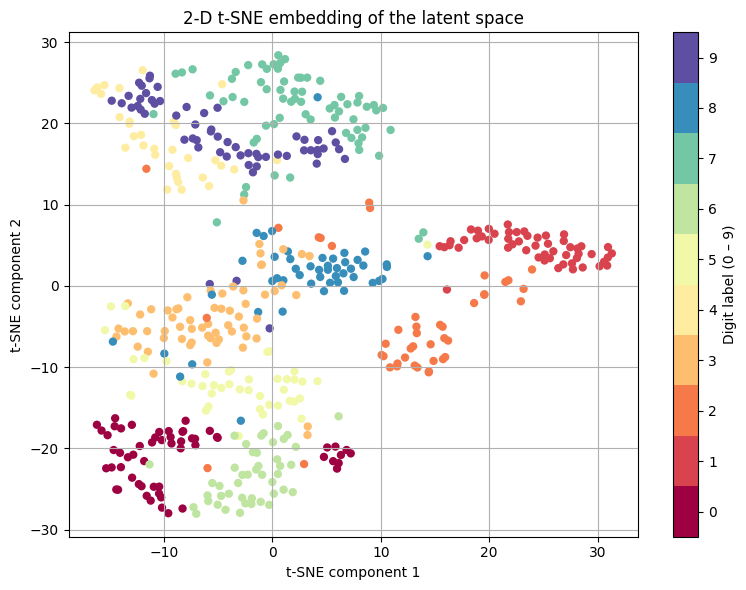

In [24]:
dataloader = DataLoader(data_train, batch_size=512, shuffle=True)
visualize_embeddings(model, dataloader)